In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# ĐƯỜNG DẪN
# ============================================================
FINAL_DIR  = Path("../data/processed/05_final")
SPLIT_DIR  = Path("../data/processed/02_split")
OUTPUT_DIR = Path("../data/processed/07_model_ready")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# CẤU HÌNH TÊN CỘT
# ============================================================
LIKERT_COLS = [
    "likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
    "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
    "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"
]

DIEM_COLS = [
    "diem_Toan", "diem_Ly", "diem_Hoa", "diem_Sinh", "diem_Van",
    "diem_Su", "diem_Dia", "diem_Anh", "diem_Gdktpl", "diem_Tin"
]

# Mapping tên ngành -> mã ngành (39 ngành chuẩn)
TEN_TO_MA = {
    "Quản trị dịch vụ du lịch và lữ hành": 7810103, "Quản trị khách sạn": 7810201,
    "Quản trị nhà hàng và dịch vụ ăn uống": 7810202, "Khoa học dinh dưỡng và ẩm thực": 7819009,
    "Khoa học chế biến món ăn": 7819010, "Du lịch": 7810101, "Luật": 7380101,
    "Luật kinh tế": 7380107, "Ngôn ngữ Anh": 7220201, "Ngôn ngữ Trung Quốc": 7220204,
    "Công nghệ thông tin": 7480201, "An toàn thông tin": 7480202, "Khoa học dữ liệu": 7460108,
    "Kế toán": 7340301, "Tài chính ngân hàng": 7340201, "Công nghệ tài chính": 7340205,
    "Marketing": 7340115, "Thương mại điện tử": 7340122,
    "Logistics và quản lý chuỗi cung ứng": 7510605, "Quản trị kinh doanh": 7340101,
    "Kinh doanh quốc tế": 7340120, "Công nghệ dệt, may": 7540204,
    "Kinh doanh thời trang và dệt may": 7340123, "Công nghệ thực phẩm": 7540101,
    "Đảm bảo chất lượng và an toàn thực phẩm": 7540106, "Quản trị kinh doanh thực phẩm": 7340129,
    "Công nghệ chế biến thủy sản": 7540105, "Công nghệ chế tạo máy": 7510202,
    "Công nghệ kỹ thuật cơ điện tử": 7510203, "Kỹ thuật nhiệt": 7520115,
    "Công nghệ kỹ thuật điện - điện tử": 7510301,
    "Công nghệ kỹ thuật điều khiển và TĐH": 7510303, "Công nghệ kỹ thuật hóa học": 7510401,
    "Công nghệ vật liệu": 7510402, "Công nghệ sinh học": 7420201,
    "Quản lý tài nguyên và môi trường": 7850101, "Công nghệ kỹ thuật môi trường": 7510406,
    "Trí tuệ nhân tạo": 7480107, "Quản lý Công nghiệp": 7510601,
}
MA_TO_TEN = {v: k for k, v in TEN_TO_MA.items()}

# ============================================================
# ĐỌC DỮ LIỆU
# ============================================================
df_train_raw = pd.read_csv(FINAL_DIR / "train_final.csv")
df_test_raw  = pd.read_csv(SPLIT_DIR / "khaosat_test_KHONG_DUNG_TOI.csv")

# Bổ sung ma_nganh cho test nếu chưa có
if "ma_nganh" not in df_test_raw.columns:
    df_test_raw["ma_nganh"] = df_test_raw["nganh_hoc"].map(TEN_TO_MA)

print(f"✅ Đọc train_final: {len(df_train_raw):,} dòng")
print(f"✅ Đọc test_raw   : {len(df_test_raw):,} dòng (100% khảo sát thật)")


✅ Đọc train_final: 16,975 dòng
✅ Đọc test_raw   : 115 dòng (100% khảo sát thật)


In [7]:
# ============================================================
# FEATURE ENGINEERING & ENCODING
# ============================================================

def process_features(df):
    df_out = pd.DataFrame(index=df.index)
    
    # 1. 10 Cột Likert (int 1-5)
    for col in LIKERT_COLS:
        df_out[col] = df[col].astype(int)
        
    # 2. 10 Cột Điểm thi (float + GIỮ NGUYÊN NaN cho XGBoost)
    for col in DIEM_COLS:
        df_out[col] = pd.to_numeric(df[col], errors="coerce")
        
    # 3. Điểm trung bình các môn có dự thi
    df_out["diem_trung_binh"] = df[DIEM_COLS].mean(axis=1)
    
    # 4. Chuẩn hóa giới tính: Nữ -> Nu, sau đó map Nam: 1, Nu: 0
    gt_clean = df["gioi_tinh"].astype(str).str.strip().replace({"Nữ": "Nu"})
    df_out["gioi_tinh_ma"] = gt_clean.map({"Nam": 1, "Nu": 0}).fillna(0).astype(int)
    
    # 5. Mục tiêu nghề nghiệp (1-4)
    df_out["muc_tieu_ma"] = df["muc_tieu_ma"].astype(int)
    
    return df_out

# Xử lý đặc trưng cơ bản
X_train_base = process_features(df_train_raw)
X_test_base  = process_features(df_test_raw)

# 6. One-Hot Encoding cho Tổ hợp thi (Đảm bảo Train và Test khớp 100% cột)
train_to_hop_dummies = pd.get_dummies(df_train_raw["to_hop_thi"], prefix="to_hop", dtype=int)
test_to_hop_dummies  = pd.get_dummies(df_test_raw["to_hop_thi"],  prefix="to_hop", dtype=int)

# Khớp các cột dummy (nếu test thiếu tổ hợp nào thì điền 0)
test_to_hop_dummies = test_to_hop_dummies.reindex(columns=train_to_hop_dummies.columns, fill_value=0)

X_train = pd.concat([X_train_base, train_to_hop_dummies], axis=1)
X_test  = pd.concat([X_test_base,  test_to_hop_dummies],  axis=1)

# 7. Label Encoding cho Target (39 mã ngành -> 0..38 cho XGBoost)
unique_majors = sorted(TEN_TO_MA.values())
label_to_idx = {int(major): idx for idx, major in enumerate(unique_majors)}
idx_to_label = {idx: int(major) for idx, major in enumerate(unique_majors)}

y_train = df_train_raw["ma_nganh"].astype(int).map(label_to_idx)
y_test  = df_test_raw["ma_nganh"].astype(int).map(label_to_idx)
w_train = df_train_raw["sample_weight"].astype(float)

print(f"✅ X_train shape : {X_train.shape}")
print(f"✅ X_test shape  : {X_test.shape}")
print(f"✅ Số lượng features : {len(X_train.columns)}")
print(f"✅ Số lượng class    : {len(unique_majors)} ngành (0..{len(unique_majors)-1})")


✅ X_train shape : (16975, 38)
✅ X_test shape  : (115, 38)
✅ Số lượng features : 38
✅ Số lượng class    : 39 ngành (0..38)


In [8]:
# ============================================================
# KIỂM TRA CHẤT LƯỢNG DATASET TRƯỚC KHI LƯU
# ============================================================
print("=== KIỂM TRA CHẤT LƯỢNG (MODEL-READY AUDIT) ===\n")

# 1. Kiểm tra thứ tự và tên cột
cols_match = list(X_train.columns) == list(X_test.columns)
print(f"1. Cột X_train và X_test khớp 100%: {'✅ YES' if cols_match else '❌ NO'}")

# 2. Kiểm tra Target
null_y_train = y_train.isna().sum()
null_y_test  = y_test.isna().sum()
print(f"2. Target y_train (null: {null_y_train}): {'✅ OK' if null_y_train == 0 else '❌ LỖI'}")
print(f"   Target y_test  (null: {null_y_test}): {'✅ OK' if null_y_test == 0 else '❌ LỖI'}")
print(f"   Min class index: {y_train.min()} | Max class index: {y_train.max()}")

# 3. Kiểm tra Sample Weight
print(f"3. Sample weights phân bố: {dict(w_train.value_counts())}")

# 4. Tỷ lệ NaN trong các cột Điểm thi (XGBoost tự xử lý NaN)
print("\n4. Tỷ lệ NaN ở các cột điểm thi (XGBoost Missing-Value Aware):")
nan_summary = X_train[DIEM_COLS].isna().mean() * 100
for col, pct in nan_summary.items():
    print(f"   • {col:<14}: {pct:>5.1f}% NaN")

# 5. Kiểm tra không có NaN ở Likert & Giới tính & Mục tiêu & Tổ hợp
non_diem_cols = [c for c in X_train.columns if c not in DIEM_COLS]
nan_non_diem = X_train[non_diem_cols].isna().sum().sum()
print(f"\n5. Các cột phi điểm thi (Likert, Giới tính, Tổ hợp...) có NaN không: "
      f"{'✅ Không có (0 NaN)' if nan_non_diem == 0 else f'❌ Có {nan_non_diem} NaN'}")


=== KIỂM TRA CHẤT LƯỢNG (MODEL-READY AUDIT) ===

1. Cột X_train và X_test khớp 100%: ✅ YES
2. Target y_train (null: 0): ✅ OK
   Target y_test  (null: 0): ✅ OK
   Min class index: 0 | Max class index: 38
3. Sample weights phân bố: {1.0: 16324, 10.0: 651}

4. Tỷ lệ NaN ở các cột điểm thi (XGBoost Missing-Value Aware):
   • diem_Toan     :   2.1% NaN
   • diem_Ly       :  51.9% NaN
   • diem_Hoa      :  52.9% NaN
   • diem_Sinh     :  94.8% NaN
   • diem_Van      :  60.1% NaN
   • diem_Su       :  98.8% NaN
   • diem_Dia      :  97.9% NaN
   • diem_Anh      :  41.8% NaN
   • diem_Gdktpl   :  99.8% NaN
   • diem_Tin      :  99.9% NaN

5. Các cột phi điểm thi (Likert, Giới tính, Tổ hợp...) có NaN không: ✅ Không có (0 NaN)


In [9]:
# ============================================================
# LƯU FILE SẴN SÀNG CHO TRAINING XGBOOST
# ============================================================

# 1. Lưu các file đã tách riêng (X, y, w) để nạp thẳng vào model
X_train.to_csv(OUTPUT_DIR / "X_train.csv", index=False)
y_train.to_csv(OUTPUT_DIR / "y_train.csv", index=False, header=["target"])
w_train.to_csv(OUTPUT_DIR / "w_train.csv", index=False, header=["sample_weight"])

X_test.to_csv(OUTPUT_DIR / "X_test.csv", index=False)
y_test.to_csv(OUTPUT_DIR / "y_test.csv", index=False, header=["target"])

# 2. Lưu BẢNG TỔNG HỢP FULL SỐ (đầy đủ Features + Target + Weight trong 1 file duy nhất)
train_encoded_full = pd.concat([X_train, y_train.rename("target"), w_train.rename("sample_weight")], axis=1)
train_encoded_full.to_csv(OUTPUT_DIR / "train_encoded_full.csv", index=False)

test_encoded_full = pd.concat([X_test, y_test.rename("target")], axis=1)
test_encoded_full.to_csv(OUTPUT_DIR / "test_encoded_full.csv", index=False)

# 3. Lưu Metadata: Danh sách tên cột features
feature_metadata = {
    "feature_names": list(X_train.columns),
    "n_features": len(X_train.columns),
    "likert_cols": LIKERT_COLS,
    "diem_cols": DIEM_COLS,
    "to_hop_cols": [c for c in X_train.columns if c.startswith("to_hop_")]
}
with open(OUTPUT_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, ensure_ascii=False, indent=2)

# 4. Lưu Metadata: Label Encoder Mapping
label_metadata = {
    "label_to_idx": {str(k): int(v) for k, v in label_to_idx.items()},
    "idx_to_label": {str(k): int(v) for k, v in idx_to_label.items()},
    "idx_to_name":  {str(k): MA_TO_TEN[v] for k, v in idx_to_label.items()},
    "n_classes": len(unique_majors)
}
with open(OUTPUT_DIR / "label_encoder_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_metadata, f, ensure_ascii=False, indent=2)

print("=" * 65)
print(f"🎉 ĐÃ LƯU THÀNH CÔNG VÀO: {OUTPUT_DIR}")
print("=" * 65)
print(f"  • train_encoded_full.csv    : {len(train_encoded_full):,} dòng x {len(train_encoded_full.columns)} cột (BẢNG FULL SỐ)")
print(f"  • test_encoded_full.csv     : {len(test_encoded_full):,} dòng x {len(test_encoded_full.columns)} cột")
print(f"  • X_train.csv / X_test.csv  : Ma trận Features ({len(X_train.columns)} cột)")
print(f"  • y_train.csv / y_test.csv  : Nhãn ngành Target (0..38)")
print(f"  • w_train.csv               : Trọng số mẫu (10 cho thật, 1 cho GA)")
print(f"  • feature_names.json        : Metadata định nghĩa {len(X_train.columns)} features")
print(f"  • label_encoder_mapping.json: Bảng tra cứu 39 ngành học")


🎉 ĐÃ LƯU THÀNH CÔNG VÀO: ../data/processed/07_model_ready
  • train_encoded_full.csv    : 16,975 dòng x 40 cột (BẢNG FULL SỐ)
  • test_encoded_full.csv     : 115 dòng x 39 cột
  • X_train.csv / X_test.csv  : Ma trận Features (38 cột)
  • y_train.csv / y_test.csv  : Nhãn ngành Target (0..38)
  • w_train.csv               : Trọng số mẫu (10 cho thật, 1 cho GA)
  • feature_names.json        : Metadata định nghĩa 38 features
  • label_encoder_mapping.json: Bảng tra cứu 39 ngành học


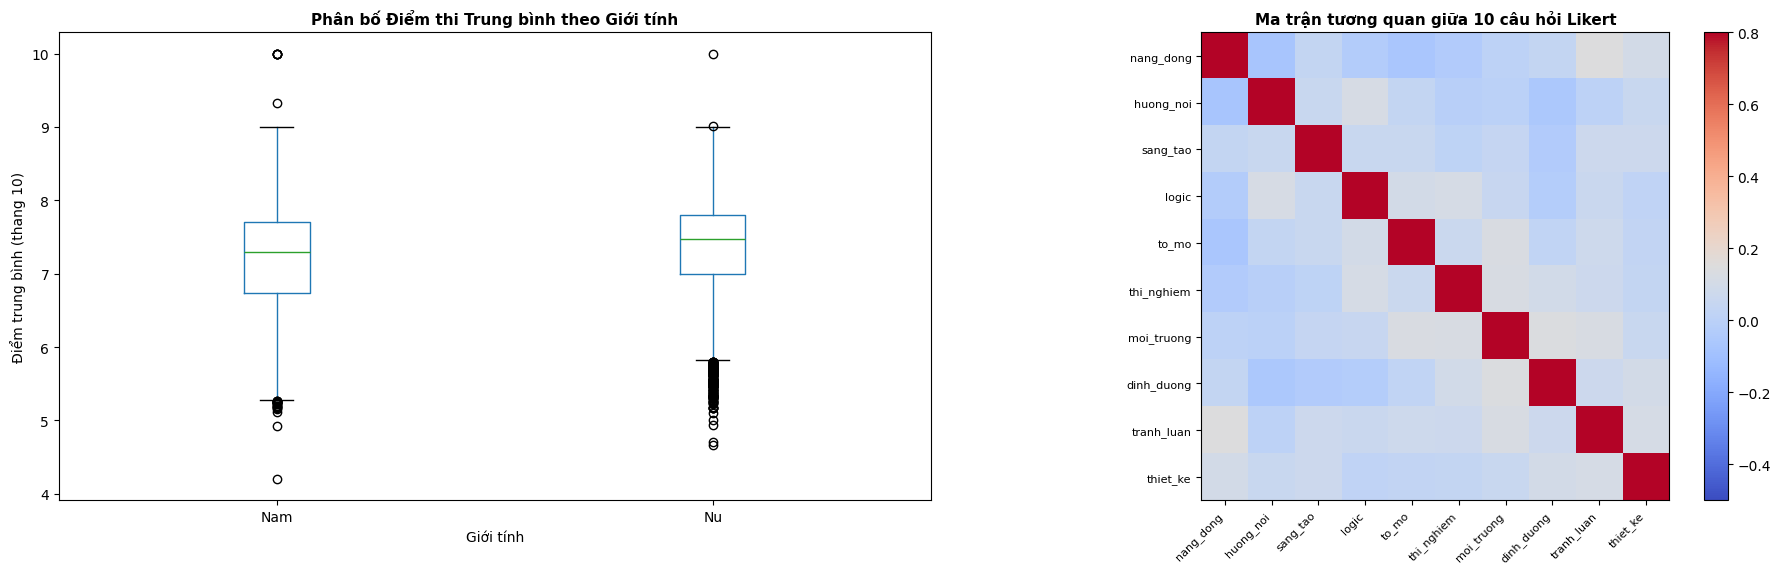

✅ Đã lưu biểu đồ: bieu_do_features_summary.png


In [10]:
# ============================================================
# BIỂU ĐỒ TRỰC QUAN HÓA FEATURES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Phân bố điểm trung bình theo giới tính
df_plot = X_train.copy()
df_plot["gioi_tinh_str"] = df_plot["gioi_tinh_ma"].map({1: "Nam", 0: "Nu"})
df_plot.boxplot(column="diem_trung_binh", by="gioi_tinh_str", ax=axes[0], grid=False)
axes[0].set_title("Phân bố Điểm thi Trung bình theo Giới tính", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Điểm trung bình (thang 10)")
plt.suptitle("")

# 2. Ma trận tương quan giữa 10 câu Likert
corr_likert = X_train[LIKERT_COLS].corr()
im = axes[1].imshow(corr_likert, cmap="coolwarm", vmin=-0.5, vmax=0.8)
axes[1].set_xticks(range(len(LIKERT_COLS)))
axes[1].set_xticklabels([c.replace("likert_","") for c in LIKERT_COLS], rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(LIKERT_COLS)))
axes[1].set_yticklabels([c.replace("likert_","") for c in LIKERT_COLS], fontsize=8)
axes[1].set_title("Ma trận tương quan giữa 10 câu hỏi Likert", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_features_summary.png", dpi=150)
plt.show()
print("✅ Đã lưu biểu đồ: bieu_do_features_summary.png")
